        Entity Code  Year  other_renewables_consumption_equivalent_twh  \
0       Africa  NaN  1971                                     0.523521   
1       Africa  NaN  1972                                     0.526714   
2       Africa  NaN  1973                                     0.542675   
3       Africa  NaN  1974                                     0.558636   
4       Africa  NaN  1975                                     0.549059   
...        ...  ...   ...                                          ...   
7110  Zimbabwe  ZWE  2019                                          NaN   
7111  Zimbabwe  ZWE  2020                                          NaN   
7112  Zimbabwe  ZWE  2021                                          NaN   
7113  Zimbabwe  ZWE  2022                                          NaN   
7114  Zimbabwe  ZWE  2023                                          NaN   

      biofuels_consumption_twh  solar_consumption_equivalent_twh  \
0                          NaN             

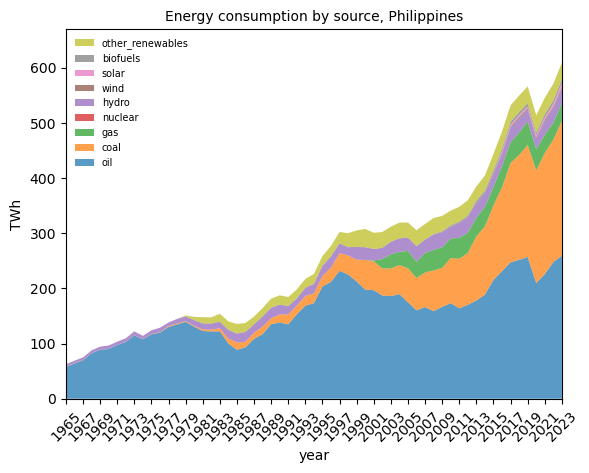

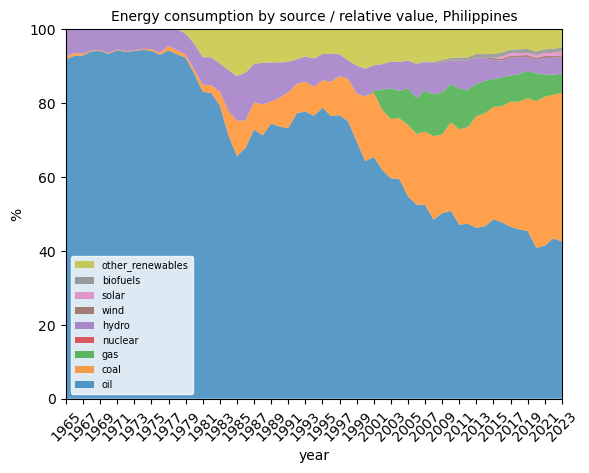

In [4]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

# Fetch the data. The User-Agent header is only necessary on google colab.
df = pd.read_csv("https://ourworldindata.org/grapher/energy-consumption-by-source-and-country.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
print(df)

code = str(input('Enter the country code you want to research.'))
data = df[df['Code']==code]
print(data)
#print(df)
data.to_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/電力源/consumption.csv')
input('Wait until you manually fill in the missing values with zeros.')
df = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/電力源/consumption.csv')
#df.fillna(0)

#df.columns = ['Entity','Code','Year','other_renewables','biofuels',\
              #'solar','wind','hydro','nuclear','gas','coal','oil']

df.columns = ['','Entity','Code','Year','other_renewables','biofuels',\
              'solar','wind','hydro','nuclear','gas','coal','oil']

cl = df.columns
#print(cl)

"""
#print(len(cl))
S = df.iloc[:,3:].sum(axis=1)
s = S/100
print(s)

l = []
for i in range(len(cl)-1, 2, -1):
    l.append(cl[i])
"""

S = df.iloc[:,4:].sum(axis=1)
s = S/100
#print(s)

l = []
for i in range(len(cl)-1, 3, -1):
    l.append(cl[i])

a = np.full(9, 0.74)

#print(l)
# Graph 1. ---------------------------------------------------------------------------
fig, ax = plt.subplots()
plt.title(f'Energy consumption by source, {df["Entity"].iloc[0]}',fontsize=10)

#plt.stackplot(df['Year'], df[cl[11]], df[cl[10]], df[cl[9]], df[cl[8]], df[cl[7]], \
 #             df[cl[6]], df[cl[5]],df[cl[4]], df[cl[3]], alpha=a, labels=l)

plt.stackplot(df['Year'], df[cl[12]], df[cl[11]], df[cl[10]], df[cl[9]], df[cl[8]], \
              df[cl[7]], df[cl[6]],df[cl[5]], df[cl[4]], alpha=a, labels=l)


plt.xticks(df['Year'][::2], fontsize=10,rotation=45)
y = range(0, int(S.max()*1.1))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, loc: '{:,}'.format(int(y))))
plt.yticks(fontsize=10)
plt.xlim(1965,2023)
plt.ylim(0, int(S.max()*1.1))
plt.xlabel('year', fontsize=10)
plt.ylabel('TWh', fontsize=10)
handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
ax.legend(handles=handles[::-1],labels=labels[::-1],labelcolor="k",facecolor='w', edgecolor='w',\
           framealpha=0.8, ncol=1, loc='upper left', fontsize=7)# 判例を逆順に表示
plt.show()


# Graph 2. ---------------------------------------------------------------------------
fig, ax = plt.subplots()
plt.title(f'Energy consumption by source / relative value, {df["Entity"].iloc[0]}',fontsize=10)


#plt.stackplot(df['Year'], df[cl[11]]/s, df[cl[10]]/s, df[cl[9]]/s,\
 #             df[cl[8]]/s, df[cl[7]]/s, df[cl[6]]/s, df[cl[5]]/s,\
  #            df[cl[4]]/s, df[cl[3]]/s, alpha=a,labels=l)


plt.stackplot(df['Year'], df[cl[12]]/s, df[cl[11]]/s, df[cl[10]]/s,\
              df[cl[9]]/s, df[cl[8]]/s, df[cl[7]]/s, df[cl[6]]/s,\
              df[cl[5]]/s, df[cl[4]]/s, alpha=a,labels=l)


plt.xticks(df['Year'][::2], fontsize=10,rotation=45)
y = range(0, 100)
plt.yticks(fontsize=10)
plt.xlim(1965,2023)
plt.ylim(0, 100)
plt.xlabel('year', fontsize=10)
plt.ylabel('%', fontsize=10)
handles, labels = ax.get_legend_handles_labels()# 凡例の情報を取得
ax.legend(handles=handles[::-1],labels=labels[::-1],labelcolor="k",facecolor='w', edgecolor='w',\
           framealpha=0.8, ncol=1, loc='lower left', fontsize=7)# 判例を逆順に表示
plt.show()